# OpenI 5,000 Image Scan + SPAI Inference + W&B (Offline)

This notebook:
- indexes up to 5,000 images from the OpenI directory,
- runs SPAI inference,
- visualizes score and image distributions with Matplotlib,
- logs metrics, tables, and figures to Weights & Biases (offline mode by default).
- All outputs are also saved locally to `OUTPUT_DIR`.

## 1. Install and Import Dependencies

In [ ]:
# If needed, install missing packages into the active kernel.
import sys
import subprocess

required = ["wandb", "matplotlib", "pandas", "Pillow", "tqdm", "numpy"]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", *required], check=False)

import os
import json
import random
import pathlib
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import wandb

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

## 2. Set Dataset Path, Limits, and W&B Configuration

In [ ]:
# Paths and run configuration
IMAGE_DIR = pathlib.Path(r"E:/research/spai/spai/data/dataset/openi/home/data_storage/mimic-cxr/dataset/open_i/image_preprocessing/512_3ch")
MODEL_PATH = pathlib.Path(r"E:/research/spai/spai/weights/spai.pth")
CFG_PATH = pathlib.Path(r"E:/research/spai/spai/configs/spai.yaml")
OUTPUT_DIR = pathlib.Path(r"E:/tmp/spai_openi_eval")

MAX_IMAGES = 5000
RANDOM_SEED = 42
SCORE_THRESHOLD = 0.5
SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

WANDB_PROJECT = "spai-openi-eval"
WANDB_ENTITY = None  # set if needed
WANDB_RUN_NAME = "openi-5000"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

assert IMAGE_DIR.exists(), f"Image directory not found: {IMAGE_DIR}"
assert MODEL_PATH.exists(), f"Model file not found: {MODEL_PATH}"
assert CFG_PATH.exists(), f"Config file not found: {CFG_PATH}"

print(f"IMAGE_DIR: {IMAGE_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"MAX_IMAGES: {MAX_IMAGES}")

## 3. Index and Select 5,000 Image Files

In [ ]:
all_images = [p for p in IMAGE_DIR.rglob("*") if p.suffix.lower() in SUPPORTED_EXTENSIONS]
all_images = sorted(all_images)

rng = random.Random(RANDOM_SEED)
rng.shuffle(all_images)
selected_images = all_images[: min(MAX_IMAGES, len(all_images))]

manifest_df = pd.DataFrame({
    "id": np.arange(len(selected_images), dtype=int),
    "abs_path": [str(p) for p in selected_images],
    "rel_path": [str(p.relative_to(IMAGE_DIR)).replace("\\", "/") for p in selected_images],
})
manifest_df["image"] = manifest_df["rel_path"]

# Build input CSV for SPAI infer. Paths are relative to IMAGE_DIR.
input_csv = OUTPUT_DIR / "openi_subset.csv"
infer_input_df = manifest_df[["image"]].copy()
infer_input_df["split"] = "test"
infer_input_df["class"] = "1"  # dummy class required by current loader
infer_input_df.to_csv(input_csv, index=False)

print(f"Total found images: {len(all_images)}")
print(f"Selected images: {len(selected_images)}")
print(f"Inference input CSV: {input_csv}")
manifest_df.head()

## 4. Load Images Safely and Track Read Failures

In [ ]:
def safe_load_image(path: pathlib.Path) -> tuple[Optional[np.ndarray], dict]:
    meta = {
        "abs_path": str(path),
        "image": path.name,
        "read_ok": False,
        "width": np.nan,
        "height": np.nan,
        "channels": np.nan,
        "dtype": "",
        "error": "",
    }
    try:
        with Image.open(path) as img:
            img = img.convert("RGB")
            arr = np.array(img)
        meta["read_ok"] = True
        meta["height"], meta["width"] = arr.shape[:2]
        meta["channels"] = arr.shape[2] if arr.ndim == 3 else 1
        meta["dtype"] = str(arr.dtype)
        return arr, meta
    except Exception as exc:
        meta["error"] = str(exc)
        return None, meta

records = []
preview_cache = {}
for p in tqdm(selected_images, desc="Reading image metadata"):
    arr, rec = safe_load_image(p)
    records.append(rec)
    # Cache only a few successful images for fast preview.
    if arr is not None and len(preview_cache) < 256:
        preview_cache[str(p)] = arr

meta_df = pd.DataFrame(records)
failed_df = meta_df[~meta_df["read_ok"]].copy()
print(f"Read success: {meta_df['read_ok'].sum()} / {len(meta_df)}")
print(f"Read failures: {len(failed_df)}")
failed_df.head()

## 5. Visualize Random Samples with Matplotlib

In [ ]:
def get_image_array(path_str: str) -> Optional[np.ndarray]:
    if path_str in preview_cache:
        return preview_cache[path_str]
    arr, _ = safe_load_image(pathlib.Path(path_str))
    return arr


def plot_image_grid(paths: list[str], title: str, cols: int = 4, max_items: int = 16):
    paths = paths[:max_items]
    if not paths:
        print("No images to display")
        return None

    rows = int(np.ceil(len(paths) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 3.2))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for i, p in enumerate(paths):
        arr = get_image_array(p)
        if arr is not None:
            axes[i].imshow(arr)
            axes[i].set_title(pathlib.Path(p).name[:30], fontsize=8)
        else:
            axes[i].text(0.5, 0.5, "Unreadable", ha="center", va="center")
            axes[i].set_title(pathlib.Path(p).name[:30], fontsize=8)

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()
    return fig

sample_paths = meta_df.loc[meta_df["read_ok"], "abs_path"].sample(
    min(16, int(meta_df["read_ok"].sum())), random_state=RANDOM_SEED
).tolist()
_ = plot_image_grid(sample_paths, "Random sample images", cols=4, max_items=16)

## 6. Generate Batch Visualizer for Quick Scanning

In [ ]:
def show_batch(page: int = 0, batch_size: int = 64, cols: int = 8):
    good_paths = meta_df.loc[meta_df["read_ok"], "abs_path"].tolist()
    start = page * batch_size
    end = min(start + batch_size, len(good_paths))
    if start >= len(good_paths):
        print(f"Page out of range. Max page: {max((len(good_paths)-1)//batch_size, 0)}")
        return None
    title = f"Batch page={page}, images {start}:{end}"
    return plot_image_grid(good_paths[start:end], title=title, cols=cols, max_items=batch_size)

# Example: first page. Change page index to scan quickly.
_ = show_batch(page=0, batch_size=64, cols=8)

## 7. Compute Basic Image Statistics and Distributions

In [ ]:
# Basic dataset stats
stats = {
    "total_selected": int(len(meta_df)),
    "read_success": int(meta_df["read_ok"].sum()),
    "read_failures": int((~meta_df["read_ok"]).sum()),
    "read_success_rate": float(meta_df["read_ok"].mean()) if len(meta_df) else 0.0,
}

ok_df = meta_df[meta_df["read_ok"]].copy()
ok_df["aspect_ratio"] = ok_df["width"] / ok_df["height"]

fig_size, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(ok_df["width"], bins=40)
axes[0].set_title("Width distribution")
axes[0].set_xlabel("width")

axes[1].hist(ok_df["height"], bins=40)
axes[1].set_title("Height distribution")
axes[1].set_xlabel("height")

axes[2].hist(ok_df["aspect_ratio"], bins=40)
axes[2].set_title("Aspect ratio distribution")
axes[2].set_xlabel("width/height")

fig_size.tight_layout()
plt.show()

fig_channels, ax = plt.subplots(figsize=(6, 4))
ok_df["channels"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Channel count distribution")
ax.set_xlabel("channels")
ax.set_ylabel("count")
fig_channels.tight_layout()
plt.show()

stats

## 8. Log Samples, Figures, and Metrics to Weights & Biases

In [11]:
# Run SPAI inference for selected subset
import subprocess
import sys

cmd = [
    sys.executable,
    "-m",
    "spai",
    "infer",
    "--input",
    str(input_csv),
    "--input-csv-root-dir",
    str(IMAGE_DIR),
    "--output",
    str(OUTPUT_DIR),
    "--model",
    str(MODEL_PATH),
    "--cfg",
    str(CFG_PATH),
]

print("Running:", " ".join(cmd))
proc = subprocess.run(cmd, capture_output=True, text=True)
print(proc.stdout)
if proc.returncode != 0:
    print(proc.stderr)
    raise RuntimeError(f"SPAI inference failed with code {proc.returncode}")

=> merge config from E:\research\spai\spai\configs\spai.yaml



In [12]:
# Load SPAI results and compute prediction summaries
result_csv = OUTPUT_DIR / input_csv.name
assert result_csv.exists(), f"Result CSV not found: {result_csv}"

result_df = pd.read_csv(result_csv)
assert "spai" in result_df.columns, "Result CSV does not contain 'spai' column"

result_df["predicted_label"] = np.where(result_df["spai"] > SCORE_THRESHOLD, "ai", "real")

score_stats = {
    "count": int(result_df["spai"].count()),
    "min": float(result_df["spai"].min()),
    "max": float(result_df["spai"].max()),
    "mean": float(result_df["spai"].mean()),
    "median": float(result_df["spai"].median()),
    "std": float(result_df["spai"].std(ddof=0)),
    "pct_above_threshold": float((result_df["spai"] > SCORE_THRESHOLD).mean() * 100.0),
}

score_stats

{'count': 3547,
 'min': 7.890253416989833e-22,
 'max': 0.0046530202962458,
 'mean': 5.254823669056473e-06,
 'median': 6.746487257736077e-10,
 'std': 0.00011151780201377632,
 'pct_above_threshold': 0.0}

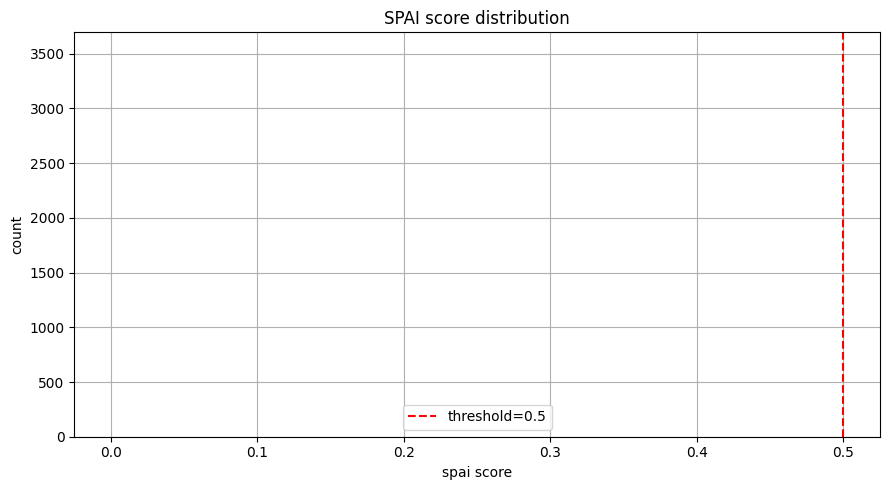

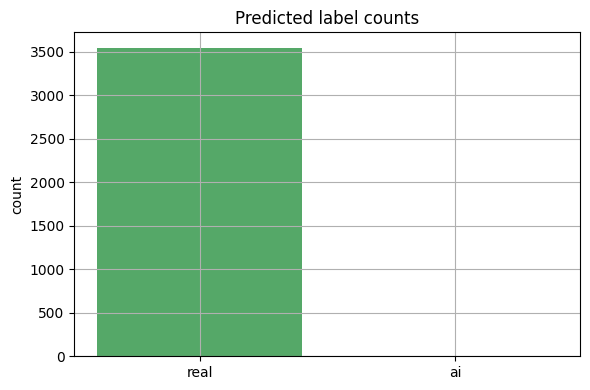

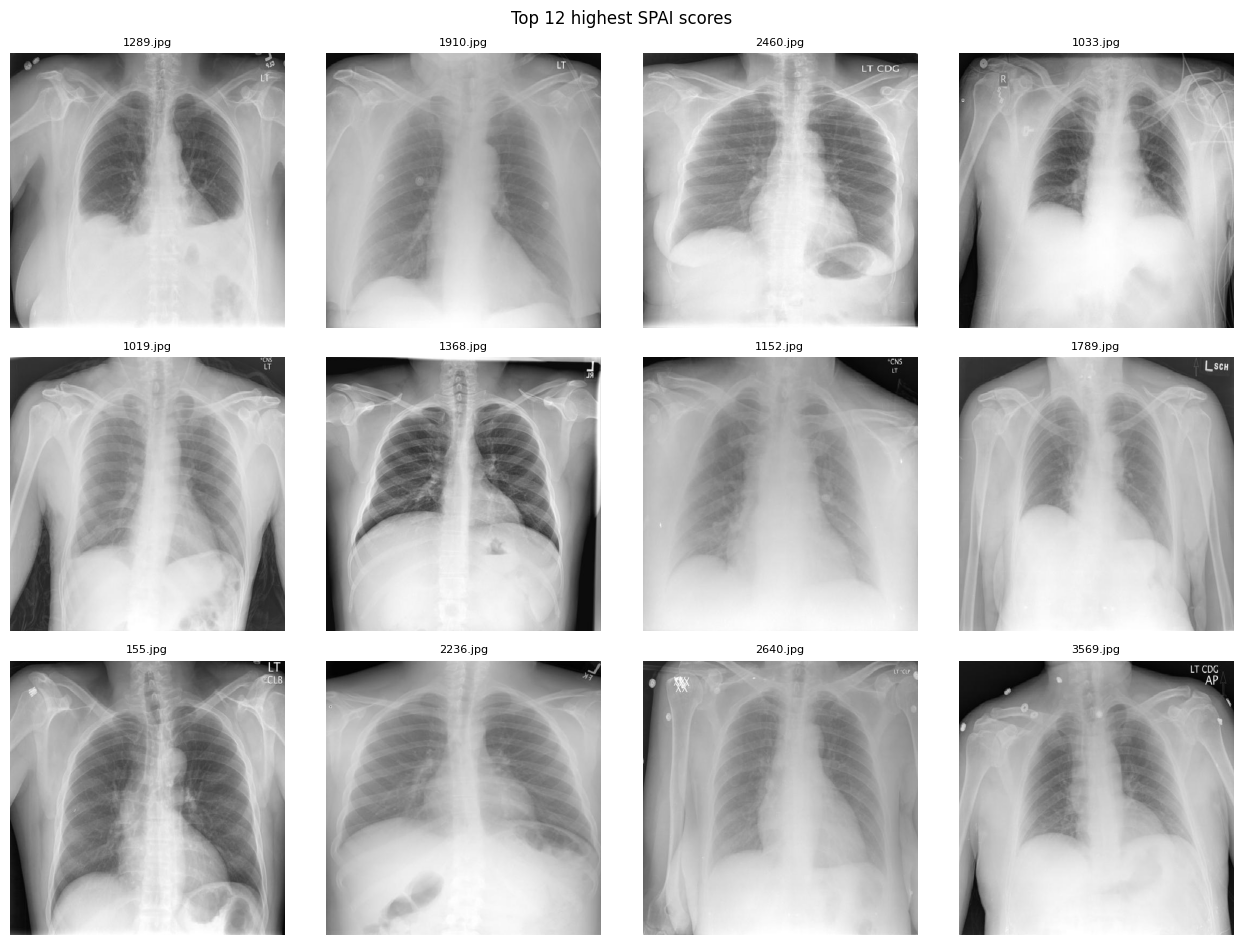

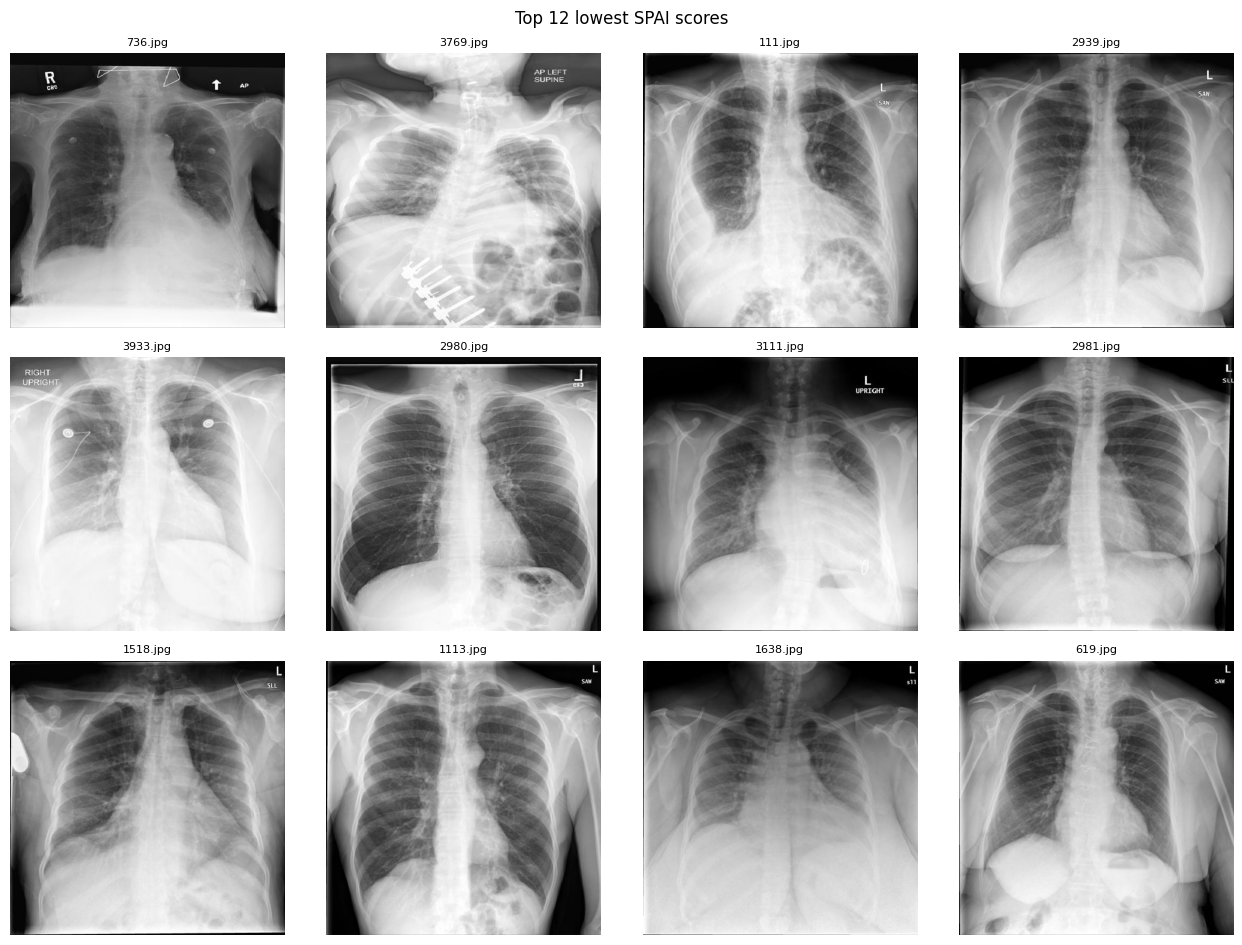

In [13]:
# Matplotlib visualizations of SPAI results
fig_hist, ax = plt.subplots(figsize=(9, 5))
ax.hist(result_df["spai"], bins=60, color="#4C72B0", alpha=0.9)
ax.axvline(SCORE_THRESHOLD, color="red", linestyle="--", label=f"threshold={SCORE_THRESHOLD}")
ax.set_title("SPAI score distribution")
ax.set_xlabel("spai score")
ax.set_ylabel("count")
ax.legend()
fig_hist.tight_layout()
plt.show()

label_counts = result_df["predicted_label"].value_counts().reindex(["real", "ai"], fill_value=0)
fig_bar, ax = plt.subplots(figsize=(6, 4))
ax.bar(label_counts.index, label_counts.values, color=["#55A868", "#C44E52"])
ax.set_title("Predicted label counts")
ax.set_ylabel("count")
fig_bar.tight_layout()
plt.show()

# Join absolute path for image grids
result_with_path = result_df.merge(manifest_df[["image", "abs_path"]], on="image", how="left")

top_ai_paths = result_with_path.sort_values("spai", ascending=False)["abs_path"].dropna().head(12).tolist()
top_real_paths = result_with_path.sort_values("spai", ascending=True)["abs_path"].dropna().head(12).tolist()

fig_top_ai = plot_image_grid(top_ai_paths, "Top 12 highest SPAI scores", cols=4, max_items=12)
fig_top_real = plot_image_grid(top_real_paths, "Top 12 lowest SPAI scores", cols=4, max_items=12)

In [14]:
# Initialize W&B and log outputs
# Make sure to run cells 1-7 before this cell!

# Set to True if you have W&B account configured, False for offline mode only
WANDB_ONLINE = False  # Change to True if you've configured W&B online

# Set environment EARLY to avoid daemon timeout issues (must be before any wandb operations)
import os
os.environ["WANDB_START_METHOD"] = "thread"

# Ensure wandb is available
import wandb

# Use W&B config from cell 2 if available, otherwise use defaults
try:
    wb_project = WANDB_PROJECT
    wb_entity = WANDB_ENTITY
    wb_run_name = WANDB_RUN_NAME
except NameError:
    print("Warning: WANDB configuration not found. Using defaults.")
    print("Make sure to run cell 2 (configuration) before this cell.")
    wb_project = "spai-openi-eval"
    wb_entity = None
    wb_run_name = "openi-5000"

wandb_run = None

if WANDB_ONLINE:
    try:
        print("Initializing W&B in online mode...")
        wandb_run = wandb.init(
            project=wb_project,
            entity=wb_entity,
            name=wb_run_name,
            config={
                "image_dir": str(IMAGE_DIR),
                "max_images": MAX_IMAGES,
                "score_threshold": SCORE_THRESHOLD,
                "model_path": str(MODEL_PATH),
                "cfg_path": str(CFG_PATH),
                "random_seed": RANDOM_SEED,
            },
        )
        print("✓ W&B online initialized successfully")
    except Exception as exc:
        print(f"✗ W&B online init failed ({exc}). Falling back to offline mode.")
        try:
            wandb_run = wandb.init(
                project=wb_project,
                entity=wb_entity,
                name=wb_run_name,
                mode="offline",
                config={
                    "image_dir": str(IMAGE_DIR),
                    "max_images": MAX_IMAGES,
                    "score_threshold": SCORE_THRESHOLD,
                    "model_path": str(MODEL_PATH),
                    "cfg_path": str(CFG_PATH),
                    "random_seed": RANDOM_SEED,
                },
            )
            print("✓ W&B offline initialized successfully")
        except Exception as exc2:
            print(f"✗ Warning: W&B init failed ({exc2}). Continuing without tracking.")
else:
    try:
        print("Initializing W&B in offline mode (data saved locally)...")
        wandb_run = wandb.init(
            project=wb_project,
            entity=wb_entity,
            name=wb_run_name,
            mode="offline",
            config={
                "image_dir": str(IMAGE_DIR),
                "max_images": MAX_IMAGES,
                "score_threshold": SCORE_THRESHOLD,
                "model_path": str(MODEL_PATH),
                "cfg_path": str(CFG_PATH),
                "random_seed": RANDOM_SEED,
            },
        )
        print("✓ W&B offline initialized successfully")
    except Exception as exc:
        print(f"✗ Warning: W&B offline init failed ({exc}). Continuing without tracking.")

if wandb_run is not None:
    merged_stats = {**stats, **score_stats}
    wandb.log(merged_stats)
    wandb.log({"spai_hist": wandb.Histogram(result_df["spai"].values)})

    if fig_hist is not None:
        wandb.log({"fig_score_hist": wandb.Image(fig_hist)})
    if fig_bar is not None:
        wandb.log({"fig_pred_bar": wandb.Image(fig_bar)})
    if fig_top_ai is not None:
        wandb.log({"fig_top_ai": wandb.Image(fig_top_ai)})
    if fig_top_real is not None:
        wandb.log({"fig_top_real": wandb.Image(fig_top_real)})

    table_df = result_with_path[["image", "spai", "predicted_label", "abs_path"]].head(200).copy()
    wandb_table = wandb.Table(dataframe=table_df)
    wandb.log({"predictions_table_head200": wandb_table})

    wandb.finish()
else:
    print("\nNote: Run outputs will be saved locally to the OUTPUT_DIR regardless of W&B status.")

wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.


Initializing W&B in offline mode (data saved locally)...
✗ Warning: W&B offline init failed (Failed to read port info after 30.0 seconds.). Continuing without tracking.

Note: Run outputs will be saved locally to the OUTPUT_DIR regardless of W&B status.


## 9. Save Run Outputs and File Manifest

In [15]:
# Save enriched outputs and metadata
pred_csv = OUTPUT_DIR / "openi_subset_with_predictions.csv"
manifest_out_csv = OUTPUT_DIR / "manifest_5000.csv"
meta_out_csv = OUTPUT_DIR / "image_read_metadata.csv"
stats_json = OUTPUT_DIR / "summary_stats.json"

result_with_path.to_csv(pred_csv, index=False)
manifest_df.to_csv(manifest_out_csv, index=False)
meta_df.to_csv(meta_out_csv, index=False)

summary_payload = {
    "dataset_stats": stats,
    "score_stats": score_stats,
    "output_files": {
        "input_csv": str(input_csv),
        "result_csv": str(result_csv),
        "pred_csv": str(pred_csv),
        "manifest_csv": str(manifest_out_csv),
        "meta_csv": str(meta_out_csv),
    },
}
with open(stats_json, "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, indent=2)

# Save figures locally
if fig_hist is not None:
    fig_hist.savefig(OUTPUT_DIR / "spai_score_hist.png", dpi=150, bbox_inches="tight")
if fig_bar is not None:
    fig_bar.savefig(OUTPUT_DIR / "predicted_label_counts.png", dpi=150, bbox_inches="tight")
if fig_top_ai is not None:
    fig_top_ai.savefig(OUTPUT_DIR / "top12_ai_like.png", dpi=150, bbox_inches="tight")
if fig_top_real is not None:
    fig_top_real.savefig(OUTPUT_DIR / "top12_real_like.png", dpi=150, bbox_inches="tight")

print("Saved outputs:")
print(f"- {pred_csv}")
print(f"- {manifest_out_csv}")
print(f"- {meta_out_csv}")
print(f"- {stats_json}")

Saved outputs:
- E:\tmp\spai_openi_eval\openi_subset_with_predictions.csv
- E:\tmp\spai_openi_eval\manifest_5000.csv
- E:\tmp\spai_openi_eval\image_read_metadata.csv
- E:\tmp\spai_openi_eval\summary_stats.json


In [16]:
print("Run complete.")
print(f"All outputs are under: {OUTPUT_DIR}")
print(f"Main prediction file: {pred_csv}")

Run complete.
All outputs are under: E:\tmp\spai_openi_eval
Main prediction file: E:\tmp\spai_openi_eval\openi_subset_with_predictions.csv
